Assignment: Autoencoders

Name of the students: Manuel Cattoni, Alessio Carnevale

## Instructions

Write your name (or names if you are working in a group) in the cell above

Write your solution in the cell below the exercise. Some cell can be already partially completed to facilitate your work. If it more conveninent for you, feel free to rewrite the entire cell/solution instead of using the pre-filled cell.

## Suggestions

Whenever possible, print the final results to check correctness of the solution. For debugging and understanding, it is sometimes convenient also to print intermediate results.

Note: We do not care about your codes!! We only care about the final results!


## Delivery

The jupyter notebook should be executed from the beginning, running the notebook as follows: `Kernel -> Restart & Run All`. Check that the printed solutions are the ones you are expecting. 

We will run your notebook. If it breaks, we will evaluate your exercise only up to the break. 

You can send the jupyter notebook to the lecturers via email.

Submission deadline: March, 31th, 2025

# Exercise

## Use Autoencoders to reconstruct images from the MNIST dataset

In this exercise, we implement an Autoencoder (AE) to reconstruct images from the MNIST dataset. Autoencoders are a type of neural network designed to learn efficient codings of input data by compressing it into a latent space and then reconstructing the original input from this compressed representation.

After training the autoencoder for image reconstruction, we will use it for:

- Image Compression
- Anomaly detection
- kNN Classification using a reduced number of features (optional, only for those who are familiar with the kNN algorithms)



### References:
- **Autoencoders (AE)**: Baldi, P. (2012). Autoencoders, unsupervised learning, and deep architectures. In Proceedings of ICML Workshop on Unsupervised and Transfer Learning (pp. 37-49).
- **MNIST Dataset**: A dataset of 70,000 28x28 grayscale images of handwritten digits (0-9). [MNIST website](http://yann.lecun.com/exdb/mnist/)
- **Fashion MNIST Dataset**: A dataset of 70,000 28x28 grayscale images of fashion images (10 classes). [Fashion MNIST website](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## Instructions

Run the following cells to:

1. Import necessary libraries.
2. Download the MNIST dataset.
3. Visualize some of the images.

Make sure to familiarize yourself with the type of data you are working with. For example, check the dimensions of the training and test sets, as well as the shape of each sample in the dataset.

In [12]:
# Importing necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader, TensorDataset


In [15]:
# Define transformations: Convert to Tensor and Normalize
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download the entire dataset and convert it to tensors
trainset = torchvision.datasets.MNIST(root='', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='', train=False, download=True, transform=transform)

# Extract images and labels
X_train = torch.stack([trainset[i][0] for i in range(len(trainset))]).squeeze()  # From shape [60000, 1, 28, 28] to [60000, 1, 28, 28]
y_train = torch.tensor([trainset[i][1] for i in range(len(trainset))])  # Shape: [60000]

X_test = torch.stack([testset[i][0] for i in range(len(testset))]).squeeze()  # From shape [10000, 1, 28, 28] to [10000, 28, 28]
y_test = torch.tensor([testset[i][1] for i in range(len(testset))])  # Shape: [10000]

# Print dataset shapes
print(f"Training set: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Test set: X_test {X_test.shape}, y_test {y_test.shape}")

OSError: [WinError 433] È stato specificato un dispositivo inesistente: 'MNIST'

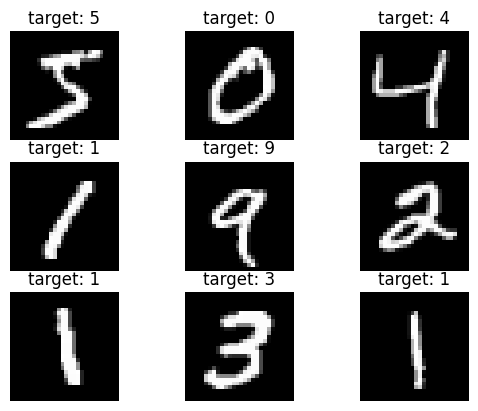

In [ ]:
# visualize the first 9 images
plt.figure

count = 0
for row in range(3):
    for col in range(3):
        plt.subplot(3, 3, count+1)
        plt.imshow(X_train[count,:], cmap='gray')
        plt.title(f"target: {y_train[count].item()}")
        plt.axis('off')
        count +=1

## Exercise 1

In this exercise, you will use the Autoencoder for Image compression.

# Task:

Condider the training images uploaded in the previous cells. Train an Autoencoder that takes these images as inputs and returns the same images. As a size for the latent variable $z$ coming as output of the encoder, you may choose $n_z \leq 30$  


# Suggested steps:

1. Create an `Encoder` as a fully connected neural network, inheriting from the class `nn.Module`. The encoder should take an input dataset $X$ and return the latent variables $z$. Implement this encoder and verify that for a given input $X$, the model outputs a variable of size $n_z$. Suggestion: As input for the encoder, reshape the pixels of the 2-D images (28x28 matrix) into a 1-D vector of size 784 (=28x28). 
 
2. Create a `Decoder` as a fully connected neural network, inheriting from the class `nn.Module`. The decoder should take as input the latent variable $z$ and reconstruct the image $X$. Specifically, the decoder will output the pixel intensities, which should take values between 0 and 1. For this reason, we suggest to use a sigmoid activation function in the final layer. Implement this decoder and verify that for a given latent variable $z$, the model outputs a vector of size 784, which can be shown as $28 \times 28$ image after reshaping.


### AE Architecture:
- The AE should be implemented as a class `Autoencoder` that inherits from `nn.Module`.
- The `forward()` method should:
   - Encode the input to the latent space using the `Encoder`.
   - Decode the latent variable $z$ to reconstruct the input using the `Decoder`.
   
The output of the AE will include the reconstructed input $\hat{X}$ and the latent variable $z$.

### Loss Function:
The total loss minimized during training can be the average of the reconstruction error RE over the dataset (or a minibatch of the dataset). As a reconstruction error, for a given image $X^{i}$, we use the mean square error:

\begin{equation}
RE = \frac{1}{784}\left\| X^{i} - \hat{X}^{i} \right\|^2
\end{equation}

where $X$ is the original input, and $\hat{X}$ is the output of the autoencoder. 

### Training:
Training a good autoencoder can require many iterations of gradient descent. Since the training dataset is pretty large (60'000 samples), completing an iteration can be time consuming. Thus, we suggest to work with mini batches of data at each iteration of gradient descent. Suggested size of the mini batch for each iteration: around 1000. 

### Debugging
After constructing Encoder, Decoder, and Autoencoder, check if the mdoel works as expected. Provide an input image and see if the output of your model has at least the shape you expect. 

In [ ]:
type(X_train)

torch.Tensor

In [ ]:
# Create the Encoder block
# You can complete the following cell or rewrite it from scratch

# Create Encoder
class Encoder(nn.Module):
    def __init__(self,H, W, nz, hidden_size_E ):
        super(Encoder, self).__init__()
        
        self.Flatter = nn.Flatten(start_dim = 1, end_dim = -1)
        self.fc1 = nn.Linear(H*W, hidden_size_E[0])
        self.fc2 = nn.Linear(hidden_size_E[0], hidden_size_E[1])
        self.fc3 = nn.Linear(hidden_size_E[1], nz)
        
        self.ReLU = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.Flatter(x)
        
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))

        z = self.fc3(x)
        return z

In [ ]:
# Create Decoder block
# You can complete the following cell or rewrite it from scratch

class Decoder(nn.Module):
    def __init__(self, H, W, nz, hidden_size_D):
        super(Decoder, self).__init__()
        
        self.fc1 = nn.Linear(nz, hidden_size_D[0])
        self.fc2 = nn.Linear(hidden_size_D[0], hidden_size_D[1])
        self.fc3 = nn.Linear(hidden_size_D[1], H*W)
        
        self.unflatten = nn.Unflatten(dim = 1, unflattened_size = (H,W))
        
        self.ReLU = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, z):
        x = self.sigmoid(self.fc1(z))
        x = self.sigmoid(self.fc2(x))
        
        x = self.fc3(x)
        
        x = self.sigmoid(x)
    
        x = self.unflatten(x)
        return x

In [ ]:
# Create Autoencoder (You can adapt this cell  based on the Encoder and Decoder models you have defined in the previous cells)

class AutoEncoder(nn.Module):
    def __init__(self, H, W, hidden_size_E, hidden_size_D, nz):
        super(AutoEncoder, self).__init__()
        # Initialize the encoder and decoder
        self.encoder = Encoder(H, W, nz, hidden_size_E)
        self.decoder = Decoder(H, W, nz, hidden_size_D)

    def forward(self, x):
        # Encode input to latent space
        z = self.encoder(x)
        # Decode latent space back to image
        reconstructed = self.decoder(z)
        return reconstructed, z  # Return reconstructed image and latent vector

Shape of Encoder output: torch.Size([10, 10])
Shape of Decoder output: torch.Size([10, 28, 28])
Shape of Autoencoder output: torch.Size([10, 28, 28])
Shape of latent vector: torch.Size([10, 10])


Text(0.5, 1.0, 'Image generated by a non-trained AE')

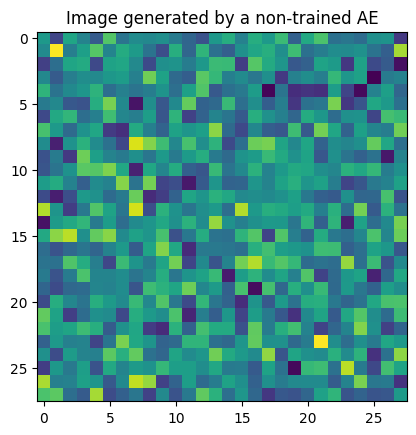

In [ ]:
### (Optional) Suggestions for checking if Encoder, Decoder, Autoencoder is working as expected


# Test the Autoencoder architecture

# Extract a set of 10 images
X = X_train[0:10, :, :]  # Shape: (10, 28, 28)
batch_size, H, W = X.shape

nz = 10  # Latent space size

hidden_size_E = [256, 128]
hidden_size_D = [128, 256]

# Define model parameters

# Instantiate the encoder model
model_encoder = Encoder(H, W, nz, hidden_size_E)
# Forward pass through the encoder
enc_im = model_encoder(X)
print(f"Shape of Encoder output: {enc_im.shape}")  # Expected size: (batch_size, nz)

# Instantiate the decoder model
model_decoder = Decoder(H, W, nz, hidden_size_D)
# Forward pass through the decoder
out = model_decoder(enc_im)
print(f"Shape of Decoder output: {out.shape}")  # Expected shape: (batch_size, 28, 28)

# Instantiate the full AutoEncoder
model = AutoEncoder(H, W, [256, 128], [128, 256], nz)
# Forward pass through the autoencoder
X_hat, z = model(X)
print(f"Shape of Autoencoder output: {X_hat.shape}")  # Expected shape: (batch_size, 28, 28)
print(f"Shape of latent vector: {z.shape}")  # Expected shape: (batch_size, nz)

# Given a value of z, we can also apply it to the decoder and generate an output
X_new = model.decoder(z)
plt.figure()
plt.imshow(X_new[0,:,:].detach())
plt.title('Image generated by a non-trained AE')

Epoch 1/20, Avg. Reconstruction error: 0.071089
Epoch 2/20, Avg. Reconstruction error: 0.060331
Epoch 3/20, Avg. Reconstruction error: 0.056196
Epoch 4/20, Avg. Reconstruction error: 0.052000
Epoch 5/20, Avg. Reconstruction error: 0.047589
Epoch 6/20, Avg. Reconstruction error: 0.043503
Epoch 7/20, Avg. Reconstruction error: 0.040135
Epoch 8/20, Avg. Reconstruction error: 0.037539
Epoch 9/20, Avg. Reconstruction error: 0.035886
Epoch 10/20, Avg. Reconstruction error: 0.034538
Epoch 11/20, Avg. Reconstruction error: 0.033286
Epoch 12/20, Avg. Reconstruction error: 0.031815
Epoch 13/20, Avg. Reconstruction error: 0.030505
Epoch 14/20, Avg. Reconstruction error: 0.029460
Epoch 15/20, Avg. Reconstruction error: 0.028563
Epoch 16/20, Avg. Reconstruction error: 0.027604
Epoch 17/20, Avg. Reconstruction error: 0.026503
Epoch 18/20, Avg. Reconstruction error: 0.025592
Epoch 19/20, Avg. Reconstruction error: 0.024798
Epoch 20/20, Avg. Reconstruction error: 0.024080


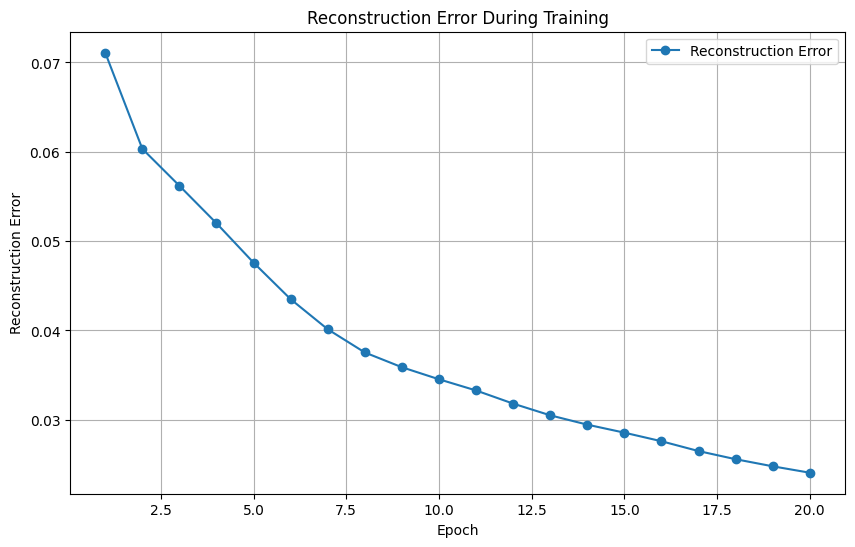

Final reconstruction error: 0.023749
Reconstruction error on a batch: 0.023525


In [ ]:
# Train the autoencoder. You can use the following reconstruction loss

def reconstruction_error(X_hat, X):
    # Mean squared error between the reconstructed images and the original images
    RE = torch.nn.functional.mse_loss(X_hat, X, reduction='mean')  # Use PyTorch's built-in MSE function
    return RE

# Parametres setted above:
# H, W = 28, 28
# nz = 10
# hidden_size_E = [256, 128]
# hidden_size_D = [128, 256]


# Create dataloader for batch
batch_size = 256
train_dataset = TensorDataset(X_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


model = AutoEncoder(H, W, hidden_size_E, hidden_size_D, nz)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

# Training loop with mini-batch
epochs = 20  # Number of training epochs
loss_history = []  # List to store the average loss for each epoch

for epoch in range(epochs):
    model.train()  
    total_loss = 0  
    for batch in train_loader:
        X_batch = batch[0]  # Extract the batch of images
        optimizer.zero_grad()  
        X_hat, _ = model(X_batch)  # Forward pass through the autoencoder
        loss = loss_fn(X_hat, X_batch)  # Compute the reconstruction loss
        loss.backward()  
        optimizer.step()  # Update the model parameters
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)  # Compute the average loss for the epoch
    loss_history.append(avg_loss)  # Salva l'errore medio per questa epoca    
    print(f"Epoch {epoch+1}/{epochs}, Avg. Reconstruction error: {avg_loss:.6f}")  

# Plot dell'errore di ricostruzione durante le epoche
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), loss_history, marker='o', label='Reconstruction Error')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Error')
plt.title('Reconstruction Error During Training')
plt.legend()
plt.grid()
plt.show()  

# Final computation of the reconstruction error on the entire training set
model.eval()  # Set the model to evaluation mode
final_loss = 0 

with torch.no_grad():
    for batch in train_loader:
        X_batch = batch[0]
        X_hat, _ = model(X_batch)
        loss = reconstruction_error(X_hat, X_batch)
        final_loss += loss.item()

avg_final_loss = final_loss / len(train_loader)
print(f"Final reconstruction error: {avg_final_loss:.6f}")

# Evaluate reconstruction error on a single mini-batch
sample_batch = next(iter(train_loader))[0]
with torch.no_grad():
    model.eval()
    recon, _ = model(sample_batch)
    RE = reconstruction_error(recon, sample_batch)
    print(f"Reconstruction error on a batch: {RE.item():.6f}")

## Visualizing AutoEncoder Reconstruction

We now visualize the performance of your trained  Autoencoder (AE) by comparing the original test images to the reconstructed images generated by the VAE.

### Steps:
1. **Pass the test images** through the trained AE to obtain the reconstructed images. 
   
2. **Plot the original and reconstructed images** in a 2x10 grid:
   - The first row will display the original images from the test set.
   - The second row will display the corresponding reconstructed images generated by the AE.

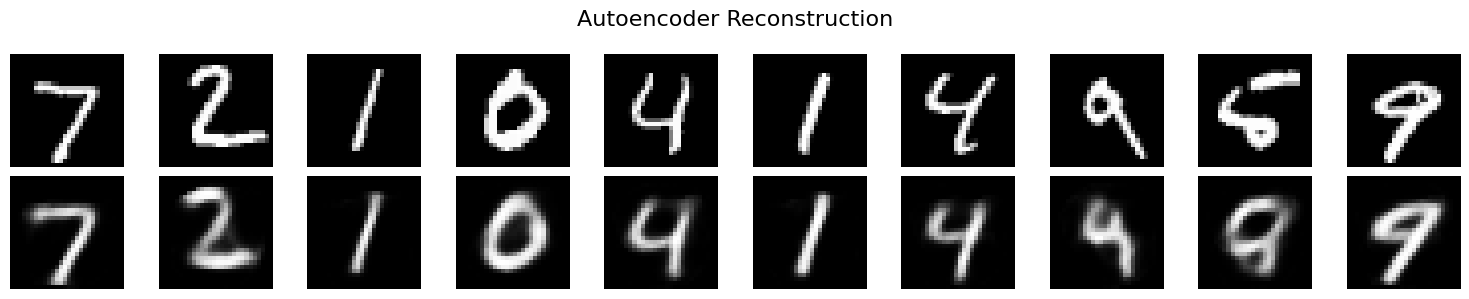

In [ ]:
X_test_sample = X_test[:10]

with torch.no_grad():
    X_reconstructed, _ = model(X_test_sample)

fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    # Original
    axes[0, i].imshow(X_test_sample[i].detach().cpu(), cmap="gray")
    axes[0, i].axis("off")

    # Recostruited
    axes[1, i].imshow(X_reconstructed[i].detach().cpu(), cmap="gray")
    axes[1, i].axis("off")

plt.suptitle("Autoencoder Reconstruction", fontsize=16)
plt.tight_layout()
plt.show()


# Check size (in MB) of an original training image and the compressed image where only the latent variable z is saved

In [ ]:
# check memory storage (you can use the following examples to see how to estimate the size of a zensor)

x_hat, z_hat = model(X_train)

size_z_hat =  z_hat.nelement()*z_hat.element_size() # number of elements of z_hat * size in bytes for each element = size in Byte of compressed tensor
size_train_images = X_train.nelement()*X_train.element_size() # size original images

print(f"size in MB of original dataset: {size_train_images/(1024**2)}") # Note: this is the size after conversion to Tensor of data type: float32 = 4 Bytes/element 
print(f"size in MB of compressed dataset: {size_z_hat/(1024**2)}")

print(f"Compression ratio: {size_train_images/size_z_hat}")
print(f"Difference in MB between original and reconstructed image: {size_train_images/(1024**2)-size_z_hat/(1024**2)}")

size in MB of original dataset: 179.443359375
size in MB of compressed dataset: 2.288818359375
Compression ratio: 78.4
Difference in MB between original and reconstructed image: 177.154541015625


# Exercise 2: Anomaly Detection

In this exercise, you should use the trained autoencoder for anomaly detection.

Anomaly detection should be performed on an extended dataset which consists of:

- all images from the MNIST dataset. These images are considered as "normal data" as the autoencoder has already been trained on the MNIST dataset (namely, on digits). 

- 10 additional images from the Fashion MNIST dataset, which should be considered as anomalies in our extended dataset

**Steps of the exercise:**

1. Create the extended dataset by concatenating the test set of MNIST with 10 images from the Fashion MNIST dataset.
   
2. Compute the reconstruction error for all the samples in the extended dataset created in step 1 and order the samples from the largest reconstruction error to the smallest.
   
3. Display the images associated with the 10 largest reconstruction errors and comment the results.

### Run the following cells to download the Fashion MNIST dataset, visualize the images and created the new dataset with test images from MNIST and 10 images from Fashion MNIST.

In [ ]:
# Load Fashion MNIST dataset

FashionMNIST_dataset_train = torchvision.datasets.FashionMNIST(root='',train=True, download=True, transform=transform)


FashionMNIST_images = torch.stack([FashionMNIST_dataset_train[i][0] for i in range(len(FashionMNIST_dataset_train))])  # Training images
FashionMNIST_images = FashionMNIST_images.squeeze()
FashionMNIST_images.shape

torch.Size([60000, 28, 28])

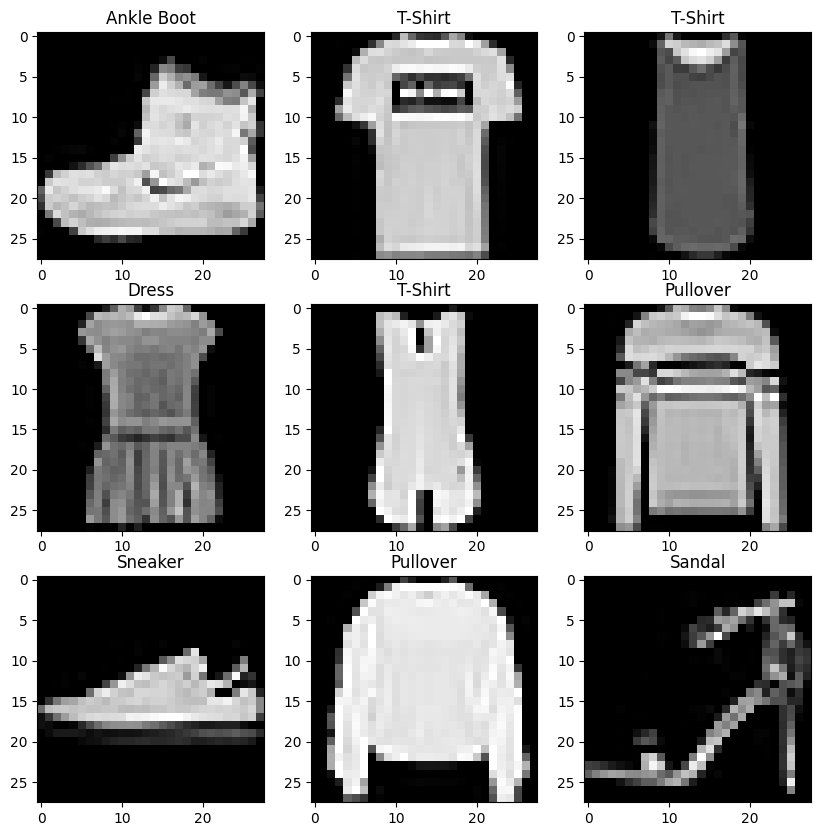

In [ ]:
# visualize data

labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}


cols, rows = 3, 3

fig = plt.figure(figsize = (10,10))
for ind in range(cols*rows):
    x, y = FashionMNIST_dataset_train[ind]
    fig.add_subplot(rows, cols, ind+1)
    plt.title(f"{labels_map[y]}")
    plt.imshow(x.squeeze(), cmap = 'gray')

In [ ]:
#1.concatanete MNIST test dataset with first 10 images of the FashionMNIST dataset

extended_dataset = torch.cat((X_test, FashionMNIST_images[0:10,:,:]), dim = 0)
print(f"Shape extended dataset: {extended_dataset.shape}")

Shape extended dataset: torch.Size([10010, 28, 28])


In [ ]:
def single_reconstruction_error(X_hat, X):
    RE = torch.nn.functional.mse_loss(X_hat, X, reduction='none')  # Keep dimensions intact
    return RE.mean(dim=(1, 2))  # Compute mean error per sample


def sort_reconstruction_errors(X_reconstructed, X_original, order='desc'):
    # Compute reconstruction errors
    reconstruction_errors = single_reconstruction_error(X_reconstructed, X_original)

    # Sort errors based on the specified order
    descending = True if order == 'desc' else False
    sorted_errors, sorted_indices = torch.sort(reconstruction_errors, descending=descending)

    return sorted_errors, sorted_indices


# Get reconstructed images by passing the extended dataset through the autoencoder
with torch.no_grad():
    X_reconstructed, _ = model(extended_dataset)

# Sort reconstruction errors in descending order
sorted_errors_desc, sorted_indices_desc = sort_reconstruction_errors(X_reconstructed, extended_dataset, order='desc')

# Sort reconstruction errors in ascending order 
sorted_errors_asc, sorted_indices_asc = sort_reconstruction_errors(X_reconstructed, extended_dataset, order='asc')

print(f"Reconstruction errors shape: {sorted_errors_desc.shape}")
print(f"Top 5 largest errors: {sorted_errors_desc[:5]}")
print(f"Top 5 smallest errors: {sorted_errors_asc[:5]}")

# largest reconstruction errors
sorted_samples_desc = extended_dataset[sorted_indices_desc]

# smallest reconstruction errors
sorted_samples_asc = extended_dataset[sorted_indices_asc]

Reconstruction errors shape: torch.Size([10010])
Top 5 largest errors: tensor([0.2058, 0.2021, 0.1469, 0.1433, 0.1033])
Top 5 smallest errors: tensor([0.0017, 0.0017, 0.0018, 0.0018, 0.0019])


Checks about reconstruction of
- best 10 recostructed
- Fashion MNIST reconstuction
- Worst 10 recustructions

In [ ]:
sorted_indices_desc

tensor([10007, 10001, 10005,  ...,  6276,  1876,  7290])

Extended dataset shape: torch.Size([10010, 28, 28])
Reconstruction errors shape: torch.Size([10010, 28, 28])


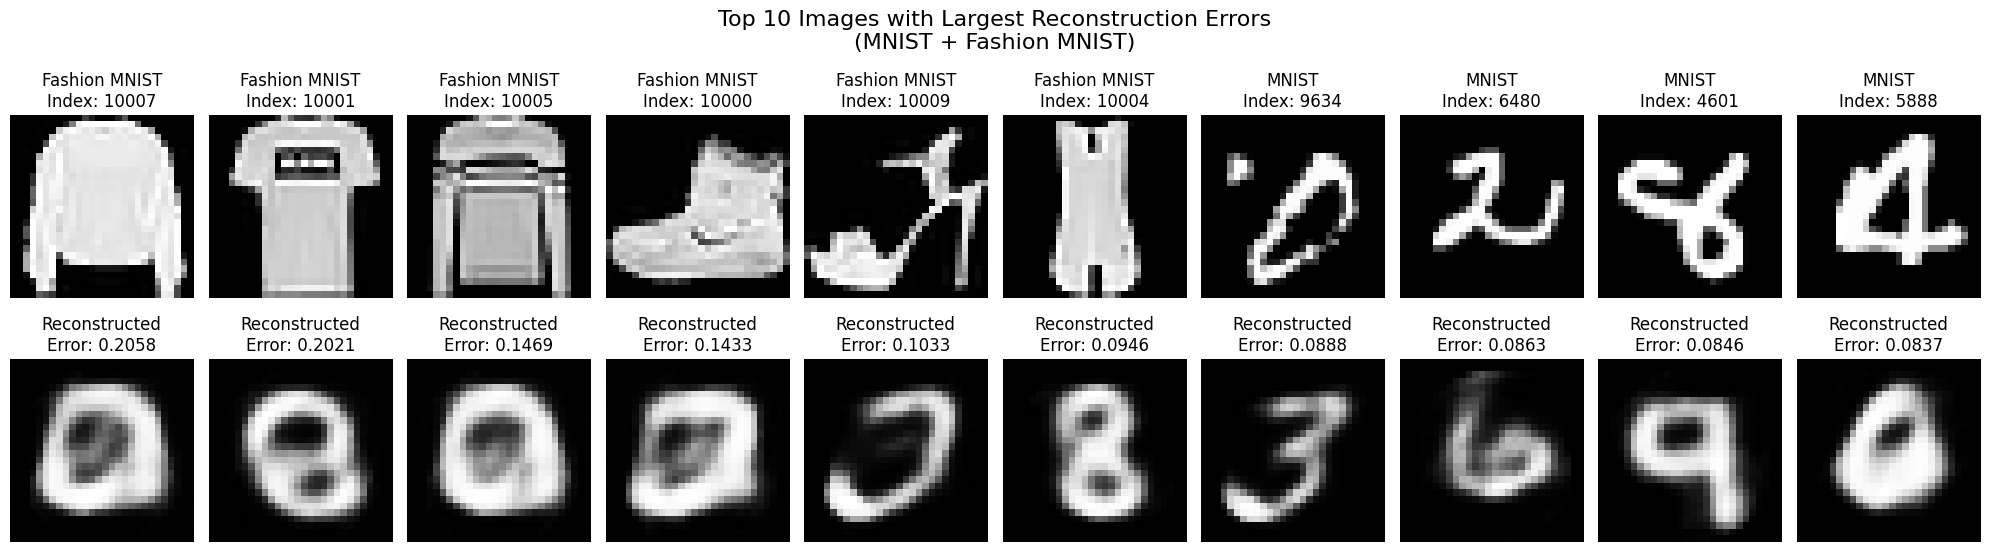

In [ ]:
# Check tensor dimensions
print(f"Extended dataset shape: {extended_dataset.shape}")
print(f"Reconstruction errors shape: {sorted_samples_asc.shape}")

# Display the images with the 10 largest reconstruction errors (worst reconstructions)
fig, axes = plt.subplots(2, 10, figsize=(20, 6))
for i in range(10):
    sample_idx = sorted_indices_desc[i]  
    
    # Determine if the sample is from MNIST or Fashion MNIST
    dataset_type = "Fashion MNIST" if sample_idx >= len(X_test) else "MNIST"
    
    # Original
    axes[0, i].imshow(extended_dataset[sample_idx].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"{dataset_type}\nIndex: {sample_idx}")
    
    # Reconstructed
    reconstructed = X_reconstructed[sample_idx]
    axes[1, i].imshow(reconstructed.squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Reconstructed\nError: {sorted_errors_desc[i]:.4f}")

plt.suptitle("Top 10 Images with Largest Reconstruction Errors\n(MNIST + Fashion MNIST)", fontsize=16)
plt.tight_layout()
plt.show()

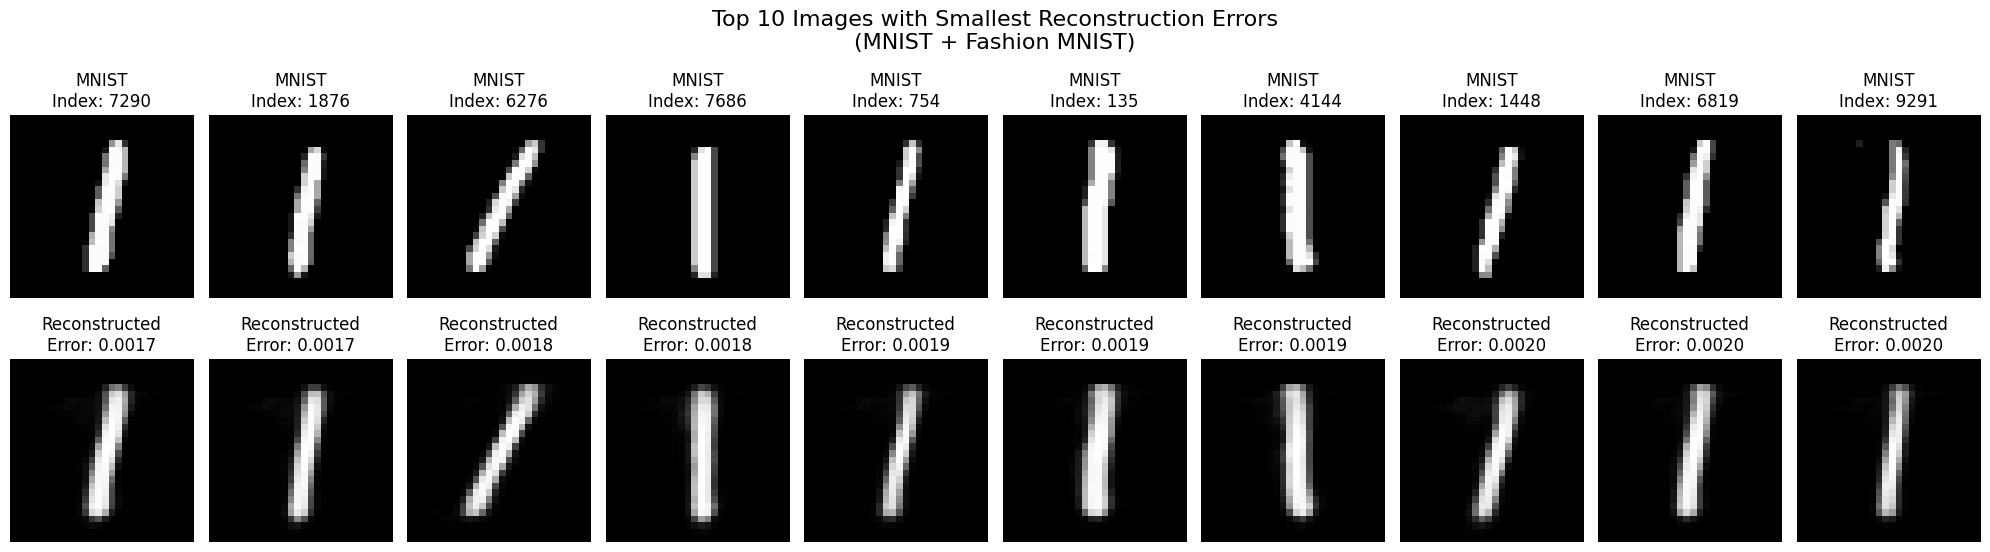

In [ ]:
# Display the images with the 10 smallest reconstruction errors (best reconstructions)
fig, axes = plt.subplots(2, 10, figsize=(20, 6))
for i in range(10):
    sample_idx = sorted_indices_asc[i]  # Convert to int for indexing
    
    # Determine if the sample is from MNIST or Fashion MNIST
    dataset_type = "Fashion MNIST" if sample_idx >= len(X_test) else "MNIST"
    
    # Original
    axes[0, i].imshow(extended_dataset[sample_idx].squeeze(), cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"{dataset_type}\nIndex: {sample_idx}")
    
    # Reconstructed
    reconstructed = X_reconstructed[sample_idx]
    axes[1, i].imshow(reconstructed.squeeze(), cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Reconstructed\nError: {sorted_errors_asc[i]:.4f}")

plt.suptitle("Top 10 Images with Smallest Reconstruction Errors\n(MNIST + Fashion MNIST)", fontsize=16)
plt.tight_layout()
plt.show()

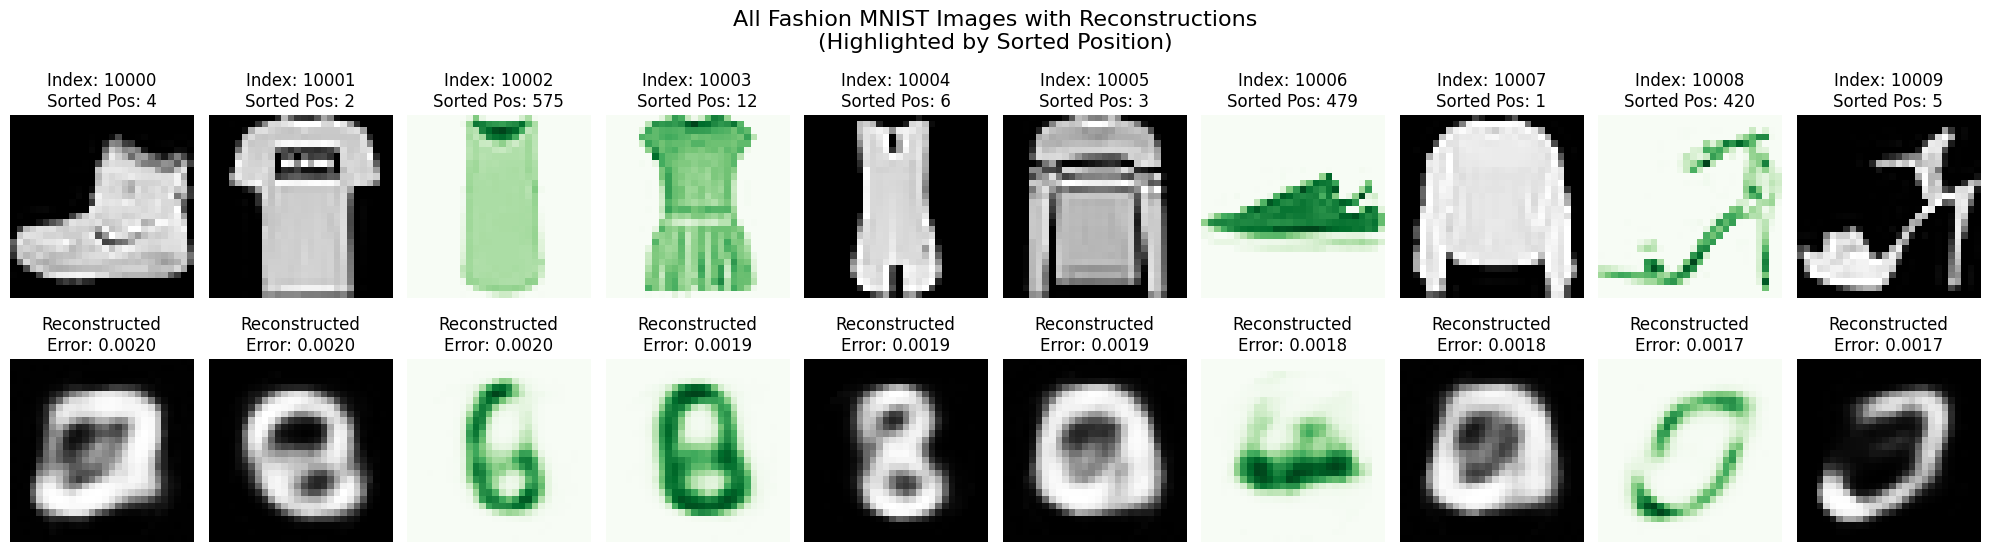

In [ ]:
# Display all images from the Fashion MNIST dataset with their reconstructions
fashion_start_idx = len(X_test)  # Assuming MNIST is first, followed by Fashion MNIST
fashion_indices = [idx for idx in range(fashion_start_idx, len(extended_dataset))]  # Indices from 1000 to 1009

fig, axes = plt.subplots(2, len(fashion_indices), figsize=(20, 6))

for i, sample_idx in enumerate(fashion_indices):
    # Find the position of the sample in the sorted errors desc
    sorted_position = (sorted_indices_desc == sample_idx).nonzero(as_tuple=True)[0].item()
    reconstruction_error = sorted_errors_desc[sample_idx].item()  # Get the reconstruction error for the sample
    
    # Determine the color based on the sorted position (to hilight the best recounstucted)
    if sorted_position > 10:
        cmap = "Greens" 
    else:
        cmap = "gray"  
    
    # Original
    axes[0, i].imshow(extended_dataset[sample_idx].squeeze(), cmap=cmap)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Index: {sample_idx}\nSorted Pos: {sorted_position+1}")
    
    # Reconstructed
    axes[1, i].imshow(X_reconstructed[sample_idx].squeeze(), cmap=cmap)
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Reconstructed\nError: {reconstruction_error:.4f}")

plt.suptitle("All Fashion MNIST Images with Reconstructions\n(Highlighted by Sorted Position)", fontsize=16)
plt.tight_layout()
plt.show()

**Comment**

In the end, the 10 worst for recostruction error are not all the 10 elements of the fashion dataset, but only 6 out of 10 are for it, so the other 4 (a vest, a dress, a sandal and a sneaker), are not that bad recostructed. We have also seen that with an higher value of nz (>25), the dress (index 10003) is ranked about 5th-7th worst, meanwhile in this case is around the 20th position.

On the other hand, obviusly, the best recounstructed are the 1, beacause are simple lines.

# Exercise 3: Classification with compressed images

Train a knn classifier to predict the digit visualized in the image.

First use original images, then the compressed images.

In both case, compute accuracy and the time taken by a kn--classificator to predict the test images. Comment the results.

In using original images, as features you should use the pixel intensity of the images (after transforming them into a vector)

For compressed, use the latent variables z.

Note: If you use sklear, do not forget to tranfor your Tensors into numpy array.

Note: In the training, use only 5000 images, otherwise the time for prediction of the k-nn algorithm will be very high
Note: in k-nn, you actually do not really train a model. Most of the time is taken to compute prediction. 

 The following cell implements the k-nn classifier on the orginal images. Feel free to use the following code or rewrite it from scratch.

In [ ]:
import numpy as np
import time
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [ ]:
# Use a subset of the training and test data for having results faster
train_images_subset = X_train[0:5000]  # Use 5000 samples from training set
train_target_subset = y_train[0:5000]  # Corresponding labels

# Flatten the images for KNN
train_images_flat = train_images_subset.view(train_images_subset.size(0), -1)  # Reshape to (batch_size, 28*28)
test_images_flat = X_test.view(X_test.size(0), -1)  # Reshape to (batch_size, 28*28)

# Convert tensors to numpy arrays for sklearn
train_images_np = train_images_flat.numpy()
test_images_np = test_images_flat.numpy()
train_target_np = train_target_subset.numpy()
test_target_np = y_test.numpy()

# Initialize the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)  # You can adjust n_neighbors for different K values

# Measure the time taken to fit the classifier
start_time = time.time()

# Fit the classifier on the training data subset
knn.fit(train_images_np, train_target_np)

# Measure the time taken to fit the model
fit_time = time.time() - start_time
print(f"Time to fit the KNN model: {fit_time:.2f} seconds")

# Measure the time taken to predict the test data
start_time = time.time()

# Predict the test labels
test_pred = knn.predict(test_images_np)

# Measure the time taken to predict the test set
predict_time = time.time() - start_time
print(f"Time to predict the test set: {predict_time:.2f} seconds")

# Compute the accuracy
accuracy = accuracy_score(test_target_np, test_pred)
print(f"Accuracy on the test set: {accuracy * 100:.2f}%")


Time to fit the KNN model: 0.01 seconds
Time to predict the test set: 2.03 seconds
Accuracy on the test set: 93.25%


In [ ]:
# Step 2: Train KNN on Compressed Images (Latent Variables z)

# Pass training and test images through the Encoder to get latent variables z
train_images_compressed = model.encoder(train_images_subset).detach().numpy()  # Shape: (5000, nz)
test_images_compressed = model.encoder(X_test).detach().numpy()  # Shape: (num_test_samples, nz)

# Initialize the KNN classifier for compressed images
knn_compressed = KNeighborsClassifier(n_neighbors = 5)

# Measure the time taken to fit the classifier on compressed images
start_time = time.time()
knn_compressed.fit(train_images_compressed, train_target_np)
fit_time_compressed = time.time() - start_time
print(f"Time to fit the KNN model (compressed): {fit_time_compressed:.2f} seconds")

# Measure the time taken to predict the test set using compressed images
start_time = time.time()
test_pred_compressed = knn_compressed.predict(test_images_compressed)
predict_time_compressed = time.time() - start_time
print(f"Time to predict the test set (compressed): {predict_time_compressed:.2f} seconds")

# Compute the accuracy for compressed images
accuracy_compressed = accuracy_score(test_target_np, test_pred_compressed)
print(f"Accuracy on the test set (compressed): {accuracy_compressed * 100:.2f}%")

Time to fit the KNN model (compressed): 0.01 seconds
Time to predict the test set (compressed): 1.45 seconds
Accuracy on the test set (compressed): 89.48%


Results for KNN on Original Images:
Accuracy: 93.25%
Time to fit the model: 0.01 seconds
Time to predict the test set: 2.03 seconds

Results for KNN on Compressed Images with nz = 10:
Accuracy: 89.48%
Time to fit the model: 0.01 seconds
Time to predict the test set: 1.45 seconds


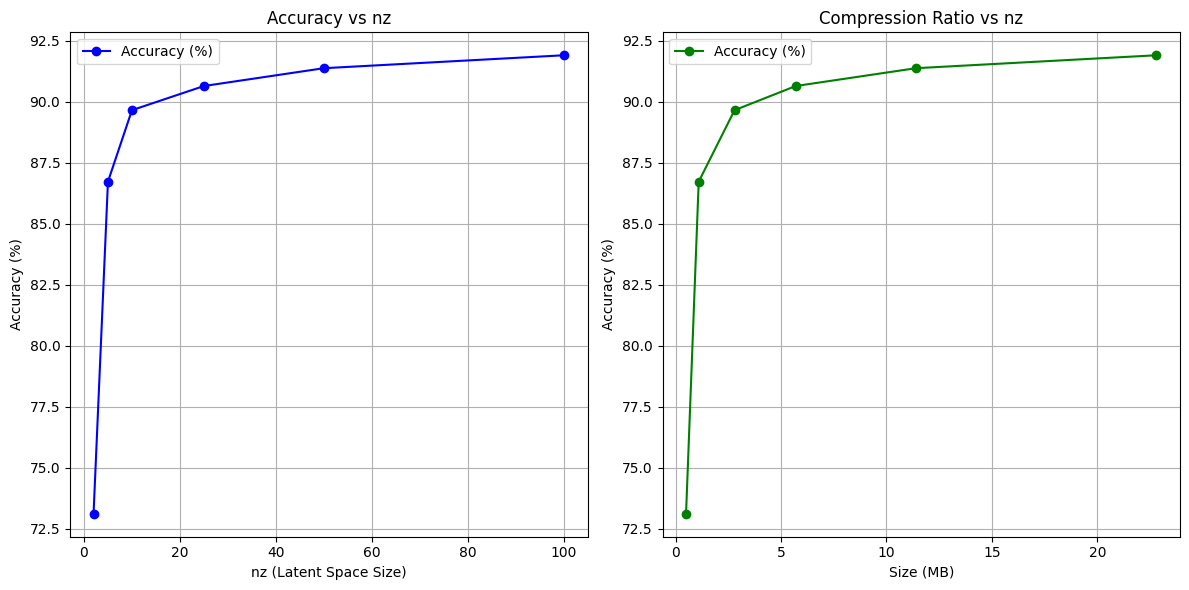

In [ ]:
# Compare the results of KNN classification on original and compressed images

print("Results for KNN on Original Images:")
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Time to fit the model: {fit_time:.2f} seconds")
print(f"Time to predict the test set: {predict_time:.2f} seconds")

print(f"\nResults for KNN on Compressed Images with nz = {nz}:")
print(f"Accuracy: {accuracy_compressed * 100:.2f}%")
print(f"Time to fit the model: {fit_time_compressed:.2f} seconds")
print(f"Time to predict the test set: {predict_time_compressed:.2f} seconds")
# plot of results
nz_values = [2, 5, 10, 25, 50, 100]
accuracies = [73.12, 86.73, 89.66, 90.65, 91.38, 91.91]  # Accuracy in percentages
total_sizes = [0.5, 1.1, 2.8, 5.7, 11.4, 22.8]  # Total size in MB
compression_ratios = [175 / size for size in total_sizes]  # Compression ratio (calculated)

# Plot accuracy vs nz
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(nz_values, accuracies, marker='o', label='Accuracy (%)', color='blue')
plt.xlabel('nz (Latent Space Size)')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs nz')
plt.grid()
plt.legend()

# Plot accuracy vs compression ratio
plt.subplot(1, 2, 2)
plt.plot(total_sizes, accuracies, marker='o', label='Accuracy (%)', color='green')
plt.xlabel('Size (MB)')
plt.ylabel('Accuracy (%)')
plt.title('Compression Ratio vs nz')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

***Comment:***

We have see that the accuracy of the model with the originl images is really good (about 93%), but with a total size of 175 MB meanwhile the compressed one could be good to, bu it obviusly depends on the value of nz. We have tried different nz: 2, 5, 10, 25, 50 and 100. 

- With nz of 2 the result wes 73.12% of accuracy, the size of the images were very little, less then 0.5 MB.

- With 5 the accuracy was of 86.73% with size of the images of 1.1MB and a compress ratio of 156.8.

- With 10 the accuracy was better, a little bit over the 89.66%, with a total size of 2.8 MB and a compress ratio of 78.4.

- With 25 the accuracy was of about 90.65%, with a total size of 5.7 MB, so a compress ratio of 31.

- With we tried 50, who had an accuracy that was around 91.38% and total size of 11.40 MB and a compress ratio of 15.7.

- For the last test we tried with 100, who had an accuracy of 91.97%, total size of 22.8 MB and a compress ratio of 7.85.


**To conclude we think that the best one was nz = 10, beause was the more bilanced between accuracy and compress ratio.** (The plots above show why)